<a href="https://colab.research.google.com/github/SemdiankinaHalyna/University-review-analysis/blob/main/text_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 71.4 MB/s eta 0:00:00


In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.3 MB/s eta 0:00:00


In [ ]:
# Import required modules and libraries
import pandas as pd
import numpy as np
import re
import ast
from string import punctuation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
import stanza
from langdetect import detect, DetectorFactory, LangDetectException
from collections import Counter
from wordcloud import WordCloud

# Build a DataFrame with only negative reviews
### This will be used for training a classification model
### and for identifying universities' key problems

In [ ]:
df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\Project\\materials\\data+bert_sentiment.csv")

In [ ]:
# Encode star rating: up to 2 — negative, 3 — neutral, 4–5 — positive
def star_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Star_Sentiment_Category'] = df['Review Rating'].apply(star_to_sentiment)

In [ ]:
# Create a column indicating whether the sentiment categories match
df['Match'] = df['Star_Sentiment_Category'] == df['Sentiment_Category_BERT']

In [ ]:
# Proportion of matches
accuracy = df['Match'].mean()
print(f"Accuracy of agreement between star rating and BERT sentiment: {accuracy:.2%}")

Accuracy of agreement between star rating and BERT sentiment: 73.31%


In [ ]:
# Filter the DataFrame based on conditions
filtered_df = df[
    (df["Sentiment_Category_BERT"] == "negative") &
    (df["Match"] == True)
]

# Select only the required columns
unlabeled_df = filtered_df[["University Name", "Review Text", "Timestamp", "Year"]].reset_index(drop=True)

# Preview the resulting DataFrame
unlabeled_df.head()

,University Name,Review Text,Timestamp,Year
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021


In [ ]:
unlabeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1866 entries, 0 to 1865
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   University Name  1866 non-null   object
 1   Review Text      1866 non-null   object
 2   Timestamp        1866 non-null   object
 3   Year             1866 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 58.4+ KB


In [ ]:
# Convert the 'Timestamp' column to datetime format, setting invalid parsing as NaT
unlabeled_df["Timestamp"] = pd.to_datetime(unlabeled_df["Timestamp"], errors="coerce")
unlabeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1866 entries, 0 to 1865
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   University Name  1866 non-null   object        
 1   Review Text      1866 non-null   object        
 2   Timestamp        1866 non-null   datetime64[ns]
 3   Year             1866 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 58.4+ KB


In [ ]:
labeled_df = pd.read_excel("C:\\Users\\Користувач\\Desktop\\Project\\materials\\labeled_df.xlsx")

In [ ]:
# Filter the DataFrame based on conditions
filtered_df = labeled_df[
    (labeled_df["Manual_Category"] == "negative")
]

# Select only the required columns
labeled_df = filtered_df[["University Name", "Review Date", "Review Text", "Timestamp", "Year", "Attitude_Towards_Students", "Campus_conditions", "Corruption",	"Academic_Process_Management",	"Education_Quality"]].reset_index(drop=True)

# Preview the resulting DataFrame
labeled_df .tail()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
505,University_1,2025-04-16 00:00:00,Ех… І з чого б почати? Формально мінімальна оц...,NaN,NaN,0.0,1.0,0.0,0.0,0.0
506,University_1,2025-02-16 00:00:00,Це найгірший університет у світі. Будь-якому і...,NaN,NaN,0.0,0.0,0.0,1.0,0.0
507,University_1,2024-11-16 00:00:00,"Взятки беруть, топ унік. За 400 долларів можеш...",NaN,NaN,0.0,0.0,1.0,0.0,0.0
508,University_1,2024-09-16 00:00:00,Назва ВНЗ не відповідає дійсності -авіацією ту...,NaN,NaN,0.0,0.0,0.0,0.0,1.0
509,University_1,2023-09-16 00:00:00,Скажу откровенно что уровень преподавания в эт...,NaN,NaN,0.0,0.0,0.0,0.0,1.0


In [ ]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              510 non-null    object 
 1   Review Date                  510 non-null    object 
 2   Review Text                  510 non-null    object 
 3   Timestamp                    434 non-null    object 
 4   Year                         434 non-null    float64
 5   Attitude_Towards_Students    510 non-null    float64
 6   Campus_conditions            510 non-null    float64
 7   Corruption                   510 non-null    float64
 8   Academic_Process_Management  510 non-null    float64
 9   Education_Quality            510 non-null    float64
dtypes: float64(6), object(4)
memory usage: 40.0+ KB


In [ ]:
# Mask for dates containing a dot (.)
mask_dot = labeled_df['Review Date'].astype(str).str.contains(r'\.', regex=True, na=False)
# For dates containing dots, convert them to datetime using the format '%d.%m.%Y' and store in 'Timestamp'
labeled_df.loc[mask_dot, 'Timestamp'] = pd.to_datetime(labeled_df.loc[mask_dot, 'Review Date'], format='%d.%m.%Y', errors='coerce')
# Convert review dates in the 'YYYY-MM-DD' format (without dots) to datetime and assign to 'Timestamp'
labeled_df.loc[~mask_dot, 'Timestamp'] = pd.to_datetime(labeled_df.loc[~mask_dot, 'Review Date'], format='%Y-%m-%d', errors='coerce')


In [ ]:
# Convert the 'Timestamp' column to datetime format, setting invalid parsing as NaT
labeled_df["Timestamp"] = pd.to_datetime(labeled_df["Timestamp"], errors="coerce")
labeled_df['Year'] =labeled_df.Timestamp.apply(lambda x: x.year)

In [ ]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              510 non-null    object        
 1   Review Date                  510 non-null    object        
 2   Review Text                  510 non-null    object        
 3   Timestamp                    510 non-null    datetime64[ns]
 4   Year                         510 non-null    int64         
 5   Attitude_Towards_Students    510 non-null    float64       
 6   Campus_conditions            510 non-null    float64       
 7   Corruption                   510 non-null    float64       
 8   Academic_Process_Management  510 non-null    float64       
 9   Education_Quality            510 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(3)
memory usage: 40.0+ KB


# Cleaning

### Preprocess text:
- convert everything to strings,
- replace NaN, lists, numbers, or unusual formats safely (numbers are kept as strings),
- remove completely empty values,
- lowercase,
- remove unwanted punctuation,
- normalize spaces,
- filter non-letter tokens,
- join back to string

In [ ]:
# A format unification step to ensure that the data is at least in string form
def clean_text_column(df, col):
    """
    Convert a column to strings, remove empty entries, and print a summary.

    Handles NaN, numbers, lists, tuples, sets, and string literals of lists.
    Also counts rows containing 'language not supported'.
    """
    # --- Diagnostics before cleaning ---
    print(f"--- Diagnostics before cleaning: {col} ---")
    print(df[col].apply(type).value_counts())

    def to_str_text(x):
        # Replace NaN with empty string
        if pd.isna(x):
            return ""
        # Convert lists, tuples, sets to string
        if isinstance(x, (list, tuple, set)):
            return " ".join(map(str, x)).strip()
        # Convert numbers to string
        if isinstance(x, (int, float, np.integer, np.floating)):
            return str(x)
        s = str(x).strip()
        # If string is a literal list like "['a','b']", parse it
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, set)):
                    return " ".join(map(str, parsed)).strip()
            except Exception:
                pass
        # Otherwise, keep as string
        return s

    # Apply conversion directly to the same column
    df[col] = df[col].apply(to_str_text)

    # Remove empty strings
    before_count = df.shape[0]
    df = df[df[col].str.strip() != ""].copy()
    after_count = df.shape[0]

    # --- Summary after cleaning ---
    print(f"\n--- After cleaning ---")
    print(df[col].apply(type).value_counts())
    print(f"Removed empty rows: {before_count - after_count} / {before_count} "
          f"({(before_count - after_count)/before_count:.2%})")

    # --- Count 'language not supported' rows ---
    lns_count = (df[col].str.strip().str.lower() == "language not supported").sum()
    print(f"Rows containing 'language not supported': {lns_count}")

    return df

In [ ]:
unlabeled_df=clean_text_column(unlabeled_df, "Review Text")
labeled_df=clean_text_column(labeled_df, "Review Text")

--- Diagnostics before cleaning: Review Text ---
Review Text
<class 'str'>    1866
Name: count, dtype: int64

--- After cleaning ---
Review Text
<class 'str'>    1866
Name: count, dtype: int64
Removed empty rows: 0 / 1866 (0.00%)
Rows containing 'language not supported': 0
--- Diagnostics before cleaning: Review Text ---
Review Text
<class 'str'>    510
Name: count, dtype: int64

--- After cleaning ---
Review Text
<class 'str'>    510
Name: count, dtype: int64
Removed empty rows: 0 / 510 (0.00%)
Rows containing 'language not supported': 0


In [ ]:
def preprocess_text_for_embeddings(text):
    """
    Preprocess text before generating Sentence Embeddings.
    The function normalizes casing, removes unwanted punctuation,
    and ensures a clean tokenized format suitable for embedding models.
    """
    if not isinstance(text, str):
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Keep numbers as they are, allow letters, digits, spaces, apostrophes, and hyphens
    text = re.sub(r"[^\w\s\-’']", " ", text, flags=re.UNICODE)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Strip leading/trailing hyphens or apostrophes from tokens
    tokens = [w.strip("-'") for w in text.split()]

    return " ".join(tokens)

In [ ]:
unlabeled_df["Cleaned_Text"] = unlabeled_df["Review Text"].apply(preprocess_text_for_embeddings) # data cleaning for prediction

In [ ]:
labeled_df["Cleaned_Text"] = labeled_df["Review Text"].apply(preprocess_text_for_embeddings) # data cleaning for training the classification model

In [ ]:
labeled_df.head()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text
0,University_1,2021-12-09,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,1.0,0.0,0.0,0.0,0.0,по информационному праву токарева ксения серге...
1,University_1,2021-08-25,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,0.0,1.0,0.0,0.0,0.0,людоньки це моя дочку поселили в кімнату з дів...
2,University_1,2019-06-08,"Шановні вступники, якщо ви хочете зберегти сво...",2019-06-08,2019,0.0,1.0,0.0,0.0,1.0,шановні вступники якщо ви хочете зберегти свої...
3,University_1,2019-05-25,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,2019-05-25,2019,0.0,0.0,1.0,0.0,0.0,советую прокуратуре проверить отдел закупок чт...
4,University_1,2019-05-19,Не знаю як і хто а я звязав своє життя з НАУ я...,2019-05-19,2019,0.0,1.0,0.0,0.0,1.0,не знаю як і хто а я звязав своє життя з нау я...


# Lemmatization

### Use pymorphy3 for Russian text and Stanza for Ukrainian text lemmatization
### Pymorphy3 is a morphological analyzer specifically designed for the Russian language.
### Stanza is a full NLP pipeline developed by the Stanford NLP team.
### It supports many languages, including Ukrainian.

In [ ]:
# Initialize pymorphy3 morphological analyzer for Russian language
morph_ru = pymorphy3.MorphAnalyzer(lang='ru')

# Initialize Stanza pipeline for Ukrainian language
nlp_uk = stanza.Pipeline('uk', processors='tokenize,mwt,pos,lemma')

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json


INFO:stanza:Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| pos       | iu_charlm   |
| lemma     | iu_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


In [ ]:
def lemmatize_text(text):
    # Detect the language of the text
    lang = detect(text)
    print(f"Detected language: {lang}")

    # Lemmatization for Russian text
    if lang == 'ru':
        tokens = text.split()
        lemmatized_tokens = ' '.join(morph_ru.parse(word)[0].normal_form for word in tokens)
        return lemmatized_tokens

    # Lemmatization for Ukrainian text
    elif lang == 'uk':
        doc = nlp_uk(text)
        lemmatized_tokens = ' '.join(word.lemma for sent in doc.sentences for word in sent.words)
        return lemmatized_tokens

    else:
        return ["Language not supported"]

In [ ]:
unlabeled_df["Lemmatized_Text"] = unlabeled_df["Cleaned_Text"].apply(lemmatize_text)

Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected l

In [ ]:
labeled_df["Lemmatized_Text"] = labeled_df["Cleaned_Text"].apply(lemmatize_text)

Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected l

In [ ]:
# Clean text after lemmatization to ensure consistent string format
unlabeled_df=clean_text_column(unlabeled_df, "Lemmatized_Text")
labeled_df=clean_text_column(labeled_df, "Lemmatized_Text")

--- Diagnostics before cleaning: Lemmatized_Text ---
Lemmatized_Text
<class 'str'>     1858
<class 'list'>       8
Name: count, dtype: int64

--- After cleaning ---
Lemmatized_Text
<class 'str'>    1866
Name: count, dtype: int64
Removed empty rows: 0 / 1866 (0.00%)
Rows containing 'language not supported': 8
--- Diagnostics before cleaning: Lemmatized_Text ---
Lemmatized_Text
<class 'str'>    510
Name: count, dtype: int64

--- After cleaning ---
Lemmatized_Text
<class 'str'>    510
Name: count, dtype: int64
Removed empty rows: 0 / 510 (0.00%)
Rows containing 'language not supported': 0


In [ ]:
stopwords_ua = [
    "а", "але", "в", "і", "й", "та", "як", "що", "це", "ця", "цей", "цею",
    "тільки", "чи", "чиє", "чия", "хто", "коли", "де", "так", "тут",
    "там", "мій", "твій", "ваш", "наш", "його", "її", "їх", "ви", "ми", "вони",
    "з", "до", "по", "на", "із", "без", "під", "над", "від", "для",
    "якщо", "свої", "я", "який", "тих", "вона", "вони", "їхній", "такий",
    "тоді", "цеї", "ті", "та", "бо", "ось", "ще", "надто", "уже", "б", "моя", "свій",
    "своє", "йому", "нам", "їм", "мені", "просто", "про", "вас", "те",
    "при", "щоб", "тому", "них", "цього", "нас", "вже", "або", "цьому", "нау", "ти", "тебе",
    "мене", "чого", "то", "було", "були", "буде", "була", "яка", "які", "такий", "всі", "є",
    "бути", "навіть", "той", "кожен", "кожний", "перед", "якби", "будь-який", "ех",
    "то", "весь", "щось", "якийсь", "зато", "хоч", "би", "по"
]
stopwords_ru = [
    "и", "в", "во", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "только", "ее", "мне", "было", "вот", "от", "меня", "еще", "о",
    "из", "ему", "теперь", "когда", "даже", "ну", "вдруг", "ли", "если", "уже",
    "или", "нибудь", "опять", "уж", "вам", "ведь", "там", "потом", "себя", "ничего",
    "ей", "может", "они", "тут", "где", "есть", "надо", "ней", "для", "мы",
    "тебя", "их", "чем", "была", "сам", "чтоб", "без", "будто", "чего", "раз",
    "тоже", "себе", "под", "будет", "ж", "мой", "твой", "моя", "нам", "им", "это",
    "вас", "того", "те", "при", "этом", "кто", "нау", "чтобы", "этого", "свой", "быть", "такой",
    "тот", "каждый", "хотя", "если", "бы", "всё", "этот", "ещё", "который", "то", "что-то",
    "какой-то", "где-то", "как-то", "как бы", "ну", "вот", "весь", "здесь"
]
all_stopwords = set(stopwords_ru + stopwords_ua)

In [ ]:
def clean_and_remove_stopwords(text, stopwords):
    # If the input is not a string (e.g., NaN or number), return an empty string
    if not isinstance(text, str):
        return ""

    # Convert text to lowercase for normalization
    text = text.lower()

    # 🔹 Replace time patterns (e.g., 12:30, 7:05, 23:59) with the token "TIME"
    text = re.sub(r"\b\d{1,2}:\d{2}\b", "TIME", text)

    # 🔹 Replace numbers (including ones with spaces, e.g., "1 122") with the token "NUM"
    text = re.sub(r"\d+(?: \d+)*", "NUM", text)

    # 🔹 Remove punctuation, but keep apostrophes and hyphens
    text = re.sub(r"[^\w\s\-’']", " ", text, flags=re.UNICODE)

    # 🔹 Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for w in text.split():
        # Remove leading and trailing hyphens or apostrophes
        w = w.strip("-'")

        # Keep the word only if it is not empty and not a stopword
        if w and w not in stopwords:
            tokens.append(w)

    # Join the tokens back into a cleaned string
    return " ".join(tokens)

In [ ]:
# Remove stopwords after lemmatization

unlabeled_df["Lemmatized_Text"] = unlabeled_df["Lemmatized_Text"].apply(
    lambda x: clean_and_remove_stopwords(x, all_stopwords)
)

labeled_df["Lemmatized_Text"] = labeled_df["Lemmatized_Text"].apply(
    lambda x: clean_and_remove_stopwords(x, all_stopwords)
)

In [ ]:
unlabeled_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...


In [ ]:
labeled_df.head()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,Lemmatized_Text
0,University_1,2021-12-09,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,1.0,0.0,0.0,0.0,0.0,по информационному праву токарева ксения серге...,информационный право токарев ксения сергеевич ...
1,University_1,2021-08-25,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,0.0,1.0,0.0,0.0,0.0,людоньки це моя дочку поселили в кімнату з дів...,людоньки дочка поселити кімната дівчина NUM хл...
2,University_1,2019-06-08,"Шановні вступники, якщо ви хочете зберегти сво...",2019-06-08,2019,0.0,1.0,0.0,0.0,1.0,шановні вступники якщо ви хочете зберегти свої...,шановний вступник хотіти зберегти нерв здоров’...
3,University_1,2019-05-25,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,2019-05-25,2019,0.0,0.0,1.0,0.0,0.0,советую прокуратуре проверить отдел закупок чт...,советовать прокуратура проверить отдел закупка...
4,University_1,2019-05-19,Не знаю як і хто а я звязав своє життя з НАУ я...,2019-05-19,2019,0.0,1.0,0.0,0.0,1.0,не знаю як і хто а я звязав своє життя з нау я...,не знати звязати життя студент гроші коментар ...


# Remove reviews with extremely high word count

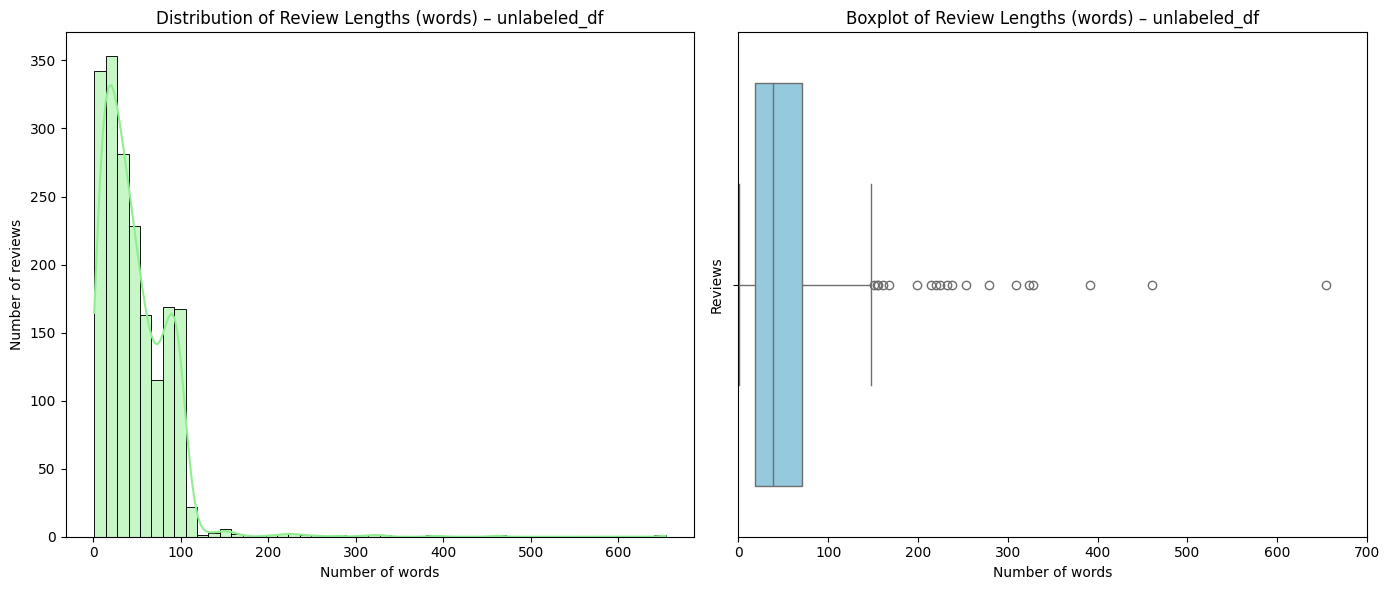

In [ ]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 700

# Compute word counts directly from text
word_lengths = unlabeled_df["Lemmatized_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = unlabeled_df[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words) – unlabeled_df")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words) – unlabeled_df")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 700)  # adjust to see the long tail

plt.tight_layout()
plt.show()

In [ ]:
# Remove reviews where the number of words > 147
unlabeled_df = unlabeled_df[
    unlabeled_df["Lemmatized_Text"].apply(lambda x: len(str(x).split())) <= 147
].copy()

# Check the remaining number of reviews
unlabeled_df.shape[0]

1844

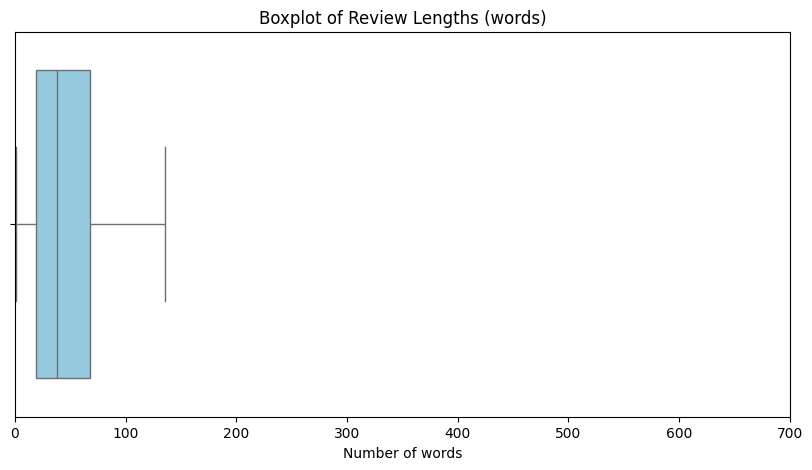

In [ ]:
# Boxplot for checking if all outlier reviews (very long texts) were removed

# Compute word counts directly from text
word_lengths = unlabeled_df["Lemmatized_Text"].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words)")
plt.xlabel("Number of words")
plt.xlim(0, 700)  # adjust to see the long tail

plt.show()

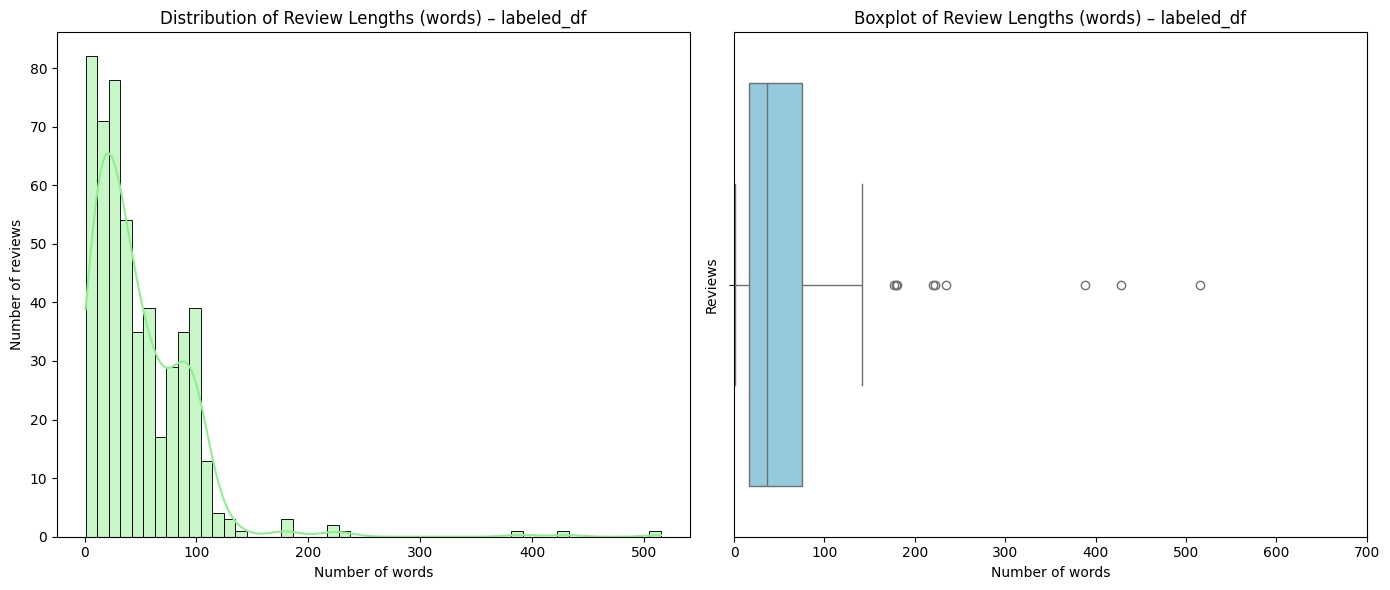

In [ ]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 700

# Compute word counts directly from text
word_lengths = labeled_df["Lemmatized_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = labeled_df[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words) – labeled_df")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words) – labeled_df")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 700)  # adjust to see the long tail

plt.tight_layout()
plt.show()

In [ ]:
# Remove reviews where the number of words > 175
labeled_df = labeled_df[
    labeled_df["Lemmatized_Text"].apply(lambda x: len(str(x).split())) <= 175]

# Check the remaining number of reviews
labeled_df.shape[0]

500

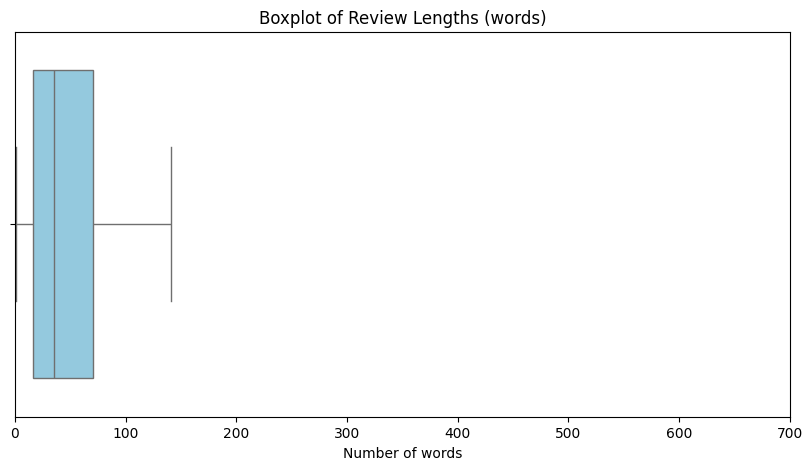

In [ ]:
# Boxplot for checking if all outlier reviews (very long texts) were removed

# Compute word counts directly from text
word_lengths = labeled_df["Lemmatized_Text"].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words)")
plt.xlabel("Number of words")
plt.xlim(0, 700)  # adjust to see the long tail

plt.show()

# Language Detection & Filtering

                 labeled %  unlabeled %
Lemmatized_Text                        
uk                    55.0    47.451193
ru                    43.4    50.488069
unknown                1.0     1.193059
bg                     0.4     0.271150
mk                     0.2     0.162690
en                     0.0     0.325380
it                     0.0     0.108460


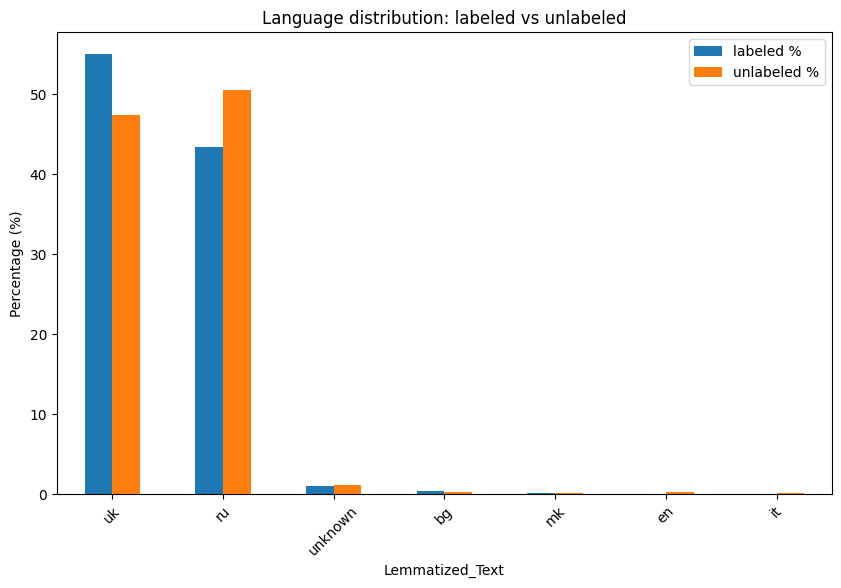

In [ ]:
def safe_detect(text):
    """
    Safely detect the language of a text.
    - Converts to string and trims whitespace
    - Returns 'unknown' if text is too short (<3 words) or detection fails
    """
    text = str(text).strip()
    if not text or len(text.split()) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

# -------------------------
# Compute language counts on the fly
# -------------------------
lang_labeled = labeled_df["Lemmatized_Text"].apply(safe_detect).value_counts(normalize=True) * 100
lang_unlabeled = unlabeled_df["Lemmatized_Text"].apply(safe_detect).value_counts(normalize=True) * 100

# Combine into one table
lang_comparison = pd.concat([lang_labeled, lang_unlabeled], axis=1, keys=["labeled %", "unlabeled %"]).fillna(0)

print(lang_comparison)

# -------------------------
# Visualization
# -------------------------
lang_comparison.plot(kind="bar", figsize=(10, 6))
plt.title("Language distribution: labeled vs unlabeled")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# to keep only rows where the detected language of the text is Ukrainian or Russian

# Set seed to make language detection results deterministic
DetectorFactory.seed = 0

def filter_uk_ru(df, text_col="Lemmatized_Text"):
    """
    Keep only rows where language is Ukrainian ('uk') or Russian ('ru').
    """
    def is_uk_or_ru(text):
        if not isinstance(text, str) or text.strip() == "":
            return False
        try:
            lang = detect(text)
            return lang in ["uk", "ru"]
        except:
            return False

    # Create mask for rows where language is 'uk' or 'ru'
    mask = df[text_col].apply(is_uk_or_ru)
    df_filtered = df[mask].copy()

    # Print statistics about filtering
    print(f"Rows before filtering: {len(df)}")
    print(f"Rows after keeping only uk/ru: {len(df_filtered)}")
    print(f"Removed rows: {len(df) - len(df_filtered)}")

    return df_filtered

In [ ]:
unlabeled_df = filter_uk_ru(unlabeled_df, text_col="Lemmatized_Text")

Rows before filtering: 1844
Rows after keeping only uk/ru: 1827
Removed rows: 17


In [ ]:
# Drop rows where safe_detect returns 'unknown'
def drop_unknown_rows(df, text_col="Lemmatized_Text"):

    mask = df[text_col].apply(lambda x: safe_detect(x) != "unknown")
    return df[mask].copy()

In [ ]:
unlabeled_df = drop_unknown_rows(unlabeled_df)

In [ ]:
unlabeled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1806 entries, 0 to 1865
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   University Name  1806 non-null   object        
 1   Review Text      1806 non-null   object        
 2   Timestamp        1806 non-null   datetime64[ns]
 3   Year             1806 non-null   int64         
 4   Cleaned_Text     1806 non-null   object        
 5   Lemmatized_Text  1806 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 98.8+ KB


In [ ]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 509
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              500 non-null    object        
 1   Review Date                  500 non-null    object        
 2   Review Text                  500 non-null    object        
 3   Timestamp                    500 non-null    datetime64[ns]
 4   Year                         500 non-null    int64         
 5   Attitude_Towards_Students    500 non-null    float64       
 6   Campus_conditions            500 non-null    float64       
 7   Corruption                   500 non-null    float64       
 8   Academic_Process_Management  500 non-null    float64       
 9   Education_Quality            500 non-null    float64       
 10  Cleaned_Text                 500 non-null    object        
 11  Lemmatized_Text              500 non-null    objec

# Merge datasets and analyze vocabulary (unique words + top words)


In [ ]:
# Combine reviews_with_predictions and reviews_labeled into full_dataset
full_df = pd.concat([unlabeled_df, labeled_df], ignore_index=True)

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              2306 non-null   object        
 1   Review Text                  2306 non-null   object        
 2   Timestamp                    2306 non-null   datetime64[ns]
 3   Year                         2306 non-null   int64         
 4   Cleaned_Text                 2306 non-null   object        
 5   Lemmatized_Text              2306 non-null   object        
 6   Review Date                  500 non-null    object        
 7   Attitude_Towards_Students    500 non-null    float64       
 8   Campus_conditions            500 non-null    float64       
 9   Corruption                   500 non-null    float64       
 10  Academic_Process_Management  500 non-null    float64       
 11  Education_Quality            500 non-null  

In [ ]:
# dropping the original date column
full_df = full_df.drop(columns=["Review Date"])

In [ ]:
full_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...,NaN,NaN,NaN,NaN,NaN
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...,NaN,NaN,NaN,NaN,NaN
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...,NaN,NaN,NaN,NaN,NaN
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...,NaN,NaN,NaN,NaN,NaN
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...,NaN,NaN,NaN,NaN,NaN


In [ ]:
def top_tokens(df, col="Lemmatized_Text", top_k=50):
    """
    Return a DataFrame with top_k tokens and their counts for the given df and column.
    Also prints the number of unique tokens.
    """
    texts = df[col].dropna().astype(str)
    tokens = []
    for t in texts:
        tokens.extend(t.split())
    counts = Counter(tokens)

    # Print number of unique tokens
    print(f"Number of unique tokens: {len(counts)}")

    # Get top-k tokens
    topk = counts.most_common(top_k)
    df_top = pd.DataFrame(topk, columns=["Token", "Count"])
    return df_top

# Top-30 for full_dataset
top_30_full = top_tokens(full_df, col="Lemmatized_Text", top_k=30)

print(top_30_full.to_string(index=False))

Number of unique tokens: 15853
        Token  Count
           не   5515
          NUM   2306
      студент   1146
     викладач    872
          вуз    617
преподаватель    540
    факультет    496
         один    471
  університет    454
          год    453
     навчання    417
          рік    410
      хороший    403
         курс    392
         пара    379
      учиться    376
      предмет    326
         мочь    312
      кафедра    312
       диплом    311
         дуже    310
  университет    304
       знание    301
          нет    293
        очень    290
       хотіти    277
       хотеть    269
        гроші    268
      человек    264
       деньга    263


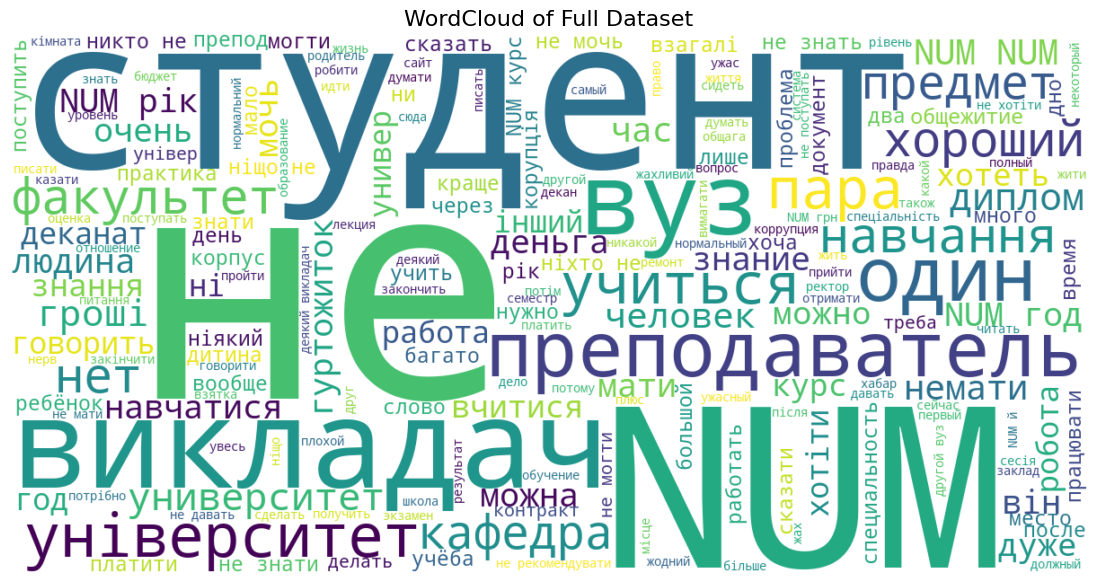

In [ ]:
# Combine all lemmatized texts into one string
all_text = " ".join(full_df["Lemmatized_Text"].dropna().astype(str))

# Create a WordCloud object
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",  # can change to "plasma", "inferno", "coolwarm", etc.
    max_words=200
).generate(all_text)

# Visualize the WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Full Dataset", fontsize=16)
plt.show()

In [ ]:
unlabeled_df.to_csv("unlabeled_df.csv", index=False, sep=";", encoding="utf-8")
labeled_df.to_csv("labeled_df.csv", index=False, sep=";", encoding="utf-8")
full_df.to_csv("full_df.csv", index=False, sep=";", encoding="utf-8")

## test_df preprocessing

In [ ]:
test_df = pd.read_excel("C:\\Users\\Користувач\\Desktop\\Project\\materials\\manual_labeling_sample.xlsx")

In [ ]:
test_df = test_df[test_df["Manual_Category"] == "negative"].reset_index(drop=True)

In [ ]:
test_df=clean_text_column(test_df, "Review Text")

--- Diagnostics before cleaning: Review Text ---
Review Text
<class 'str'>    117
Name: count, dtype: int64

--- After cleaning ---
Review Text
<class 'str'>    117
Name: count, dtype: int64
Removed empty rows: 0 / 117 (0.00%)
Rows containing 'language not supported': 0


In [ ]:
test_df["Cleaned_Text"] = test_df["Review Text"].apply(preprocess_text_for_embeddings) # data cleaning for test

In [ ]:
test_df["Lemmatized_Text"] = test_df["Cleaned_Text"].apply(lemmatize_text)

Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected l

In [ ]:
test_df=clean_text_column(test_df, "Lemmatized_Text")

--- Diagnostics before cleaning: Lemmatized_Text ---
Lemmatized_Text
<class 'str'>    117
Name: count, dtype: int64

--- After cleaning ---
Lemmatized_Text
<class 'str'>    117
Name: count, dtype: int64
Removed empty rows: 0 / 117 (0.00%)
Rows containing 'language not supported': 0


In [ ]:
test_df["Lemmatized_Text"] = test_df["Lemmatized_Text"].apply(
    lambda x: clean_and_remove_stopwords(x, all_stopwords)
)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              117 non-null    object        
 1   Review Text                  117 non-null    object        
 2   Timestamp                    117 non-null    datetime64[ns]
 3   Year                         117 non-null    int64         
 4   Manual_Category              117 non-null    object        
 5   Attitude_Towards_Students    117 non-null    float64       
 6   Campus_conditions            117 non-null    float64       
 7   Corruption                   117 non-null    float64       
 8   Academic_Process_Management  117 non-null    float64       
 9   Education_Quality            117 non-null    float64       
 10  Cleaned_Text                 117 non-null    object        
 11  Lemmatized_Text              117 non-null    

## train_df preprocessing/augmentation


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving labeled_df.xls to labeled_df (1).xls


In [ ]:
import pandas as pd
labeled_df = pd.read_csv("labeled_df.xls", sep=";", encoding="utf-8")

In [ ]:
labeled_df.head()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,Lemmatized_Text
0,University_1,2021-12-09,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,1.0,0.0,0.0,0.0,0.0,по информационному праву токарева ксения серге...,информационный право токарев ксения сергеевич ...
1,University_1,2021-08-25,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,0.0,1.0,0.0,0.0,0.0,людоньки це моя дочку поселили в кімнату з дів...,людоньки дочка поселити кімната дівчина NUM хл...
2,University_1,2019-06-08,"Шановні вступники, якщо ви хочете зберегти сво...",2019-06-08,2019,0.0,1.0,0.0,0.0,1.0,шановні вступники якщо ви хочете зберегти свої...,шановний вступник хотіти зберегти нерв здоров’...
3,University_1,2019-05-25,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,2019-05-25,2019,0.0,0.0,1.0,0.0,0.0,советую прокуратуре проверить отдел закупок чт...,советовать прокуратура проверить отдел закупка...
4,University_1,2019-05-19,Не знаю як і хто а я звязав своє життя з НАУ я...,2019-05-19,2019,0.0,1.0,0.0,0.0,1.0,не знаю як і хто а я звязав своє життя з нау я...,не знати звязати життя студент гроші коментар ...


In [ ]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              500 non-null    object 
 1   Review Date                  500 non-null    object 
 2   Review Text                  500 non-null    object 
 3   Timestamp                    500 non-null    object 
 4   Year                         500 non-null    int64  
 5   Attitude_Towards_Students    500 non-null    float64
 6   Campus_conditions            500 non-null    float64
 7   Corruption                   500 non-null    float64
 8   Academic_Process_Management  500 non-null    float64
 9   Education_Quality            500 non-null    float64
 10  Cleaned_Text                 500 non-null    object 
 11  Lemmatized_Text              500 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 47.0+ KB


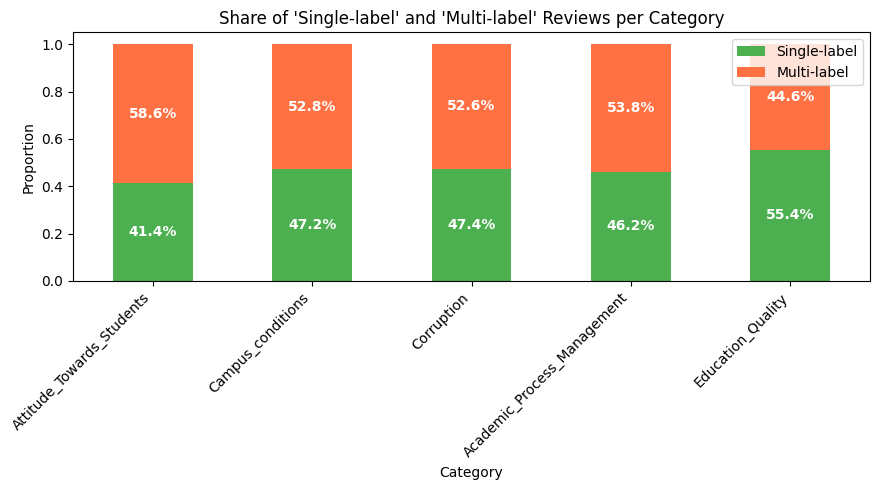

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Add a column indicating if the sample has only one label (single-label review)
labeled_df["is_single_label"] = labeled_df[label_cols].sum(axis=1) == 1

# Calculate per-category statistics
category_stats = []
for col in label_cols:
    total = labeled_df[col].sum()
    single = labeled_df.loc[labeled_df["is_single_label"], col].sum()
    multi = total - single
    category_stats.append({
        "category": col,
        "single": single,
        "multi": multi
    })

stats_df = pd.DataFrame(category_stats)

# Compute proportions
stats_df["single_share"] = stats_df["single"] / (stats_df["single"] + stats_df["multi"])
stats_df["multi_share"] = 1 - stats_df["single_share"]

# Plot stacked bar chart
ax = stats_df.set_index("category")[["single_share", "multi_share"]].plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#4CAF50", "#FF7043"]
)

plt.title("Share of 'Single-label' and 'Multi-label' Reviews per Category")
plt.ylabel("Proportion")
plt.xlabel("Category")
plt.legend(["Single-label", "Multi-label"])
plt.xticks(rotation=45, ha="right")

# Add percentage labels on the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_y() + height/2,
            f"{height*100:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()


### 🧩 Insights on Label Purity

The most **mixed categories** are **_Attitude_Towards_Students_ (58.6%)** and **_Academic_Process_Management_ (53.8%)**.  
This indicates that these labels frequently co-occur with others, which may cause the model to predict them together rather than independently.  

To address this issue, I will **augment the dataset with additional “pure” (single-label) samples** for these categories.  
This should help the model learn clearer and more distinct boundaries between classes.


In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 39.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=5d5c73dc939378232a30fe61aa788ab034d648988709b05492cbb161dab4abd8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from transformers import MarianMTModel, MarianTokenizer
import torch
from langdetect import detect
import numpy as np

In [ ]:
# Text Augmentation Function
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Translation models ---
MODELS = {
    "uk2ru": "Helsinki-NLP/opus-mt-uk-ru",
    "ru2uk": "Helsinki-NLP/opus-mt-ru-uk"
}

# --- Load tokenizers and models ---
_tokenizers = {}
_models = {}
def get_model_and_tokenizer(model_name):
    if model_name in _models:
        return _models[model_name], _tokenizers[model_name]
    tok = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name).to(device)
    _models[model_name] = model
    _tokenizers[model_name] = tok
    return model, tok

# --- Translation function ---
def translate(text, src_lang="uk"):
    if src_lang == "uk":
        model_name = MODELS["uk2ru"]
    else:
        model_name = MODELS["ru2uk"]
    model, tok = get_model_and_tokenizer(model_name)
    inputs = tok([text], return_tensors="pt", padding=True).to(device)
    translated = model.generate(**inputs, max_length=512)
    output_text = tok.decode(translated[0], skip_special_tokens=True)
    return output_text

# --- Main augmentation / translation function ---
def translate_or_paraphrase(text):
    """
    Automatically detects text language and translates between UA <-> RU.
    Returns the translated text as an augmented example.
    """
    from langdetect import detect

    if not isinstance(text, str):
        return ""

    # Remove quotation marks within text
    text = text.replace('"', '').replace("“", "").replace("”", "").replace("«", "").replace("»", "")

    try:
        lang = detect(text)
    except:
        lang = "uk"  # Default to Ukrainian if language detection fails

    if lang.startswith("uk"):
        return translate(text, src_lang="uk")
    elif lang.startswith("ru"):
        return translate(text, src_lang="ru")
    else:
        return text

In [ ]:
# 0️⃣ Label columns
label_cols = ["Attitude_Towards_Students",
              "Campus_conditions",
              "Corruption",
              "Academic_Process_Management",
              "Education_Quality"]
# --- 1️⃣ Увесь датасет як train ---
train_df = labeled_df.copy()

# --- 2️⃣ Select single-label samples ---
single_label_mask = (train_df[label_cols].sum(axis=1) == 1)
single_label_df = train_df[single_label_mask].copy()

# --- 3️⃣ Weak categories to augment ---
weak_label_names = ["Attitude_Towards_Students", "Academic_Process_Management"]

augmented_texts = []
augmented_labels = []

# --- 4️⃣ Augmentation loop ---
for label in weak_label_names:
    rows_label = single_label_df[single_label_df[label] == 1]
    if rows_label.empty:
        continue

    print(f"🔁 Augmenting {len(rows_label)} single-label samples for '{label}'")

    for idx, row in rows_label.iterrows():
        aug_text = translate_or_paraphrase(row["Review Text"])
        if not aug_text:
            continue

        augmented_texts.append(aug_text)
        augmented_labels.append(row[label_cols].values)

        # Debug print (5% випадково)
        if np.random.rand() < 0.05:
            print("Original:", row["Review Text"])
            print("Augmented:", aug_text)
            print("---")

# --- 5️⃣ Create new augmented DataFrame ---
augmented_df = pd.DataFrame(augmented_labels, columns=label_cols)
augmented_df["Review Text"] = augmented_texts

# --- 6️⃣ Combine with original train set ---
train_df = pd.concat([train_df, augmented_df], ignore_index=True)

print(f"Original train size: {len(labeled_df)}")
print(f"Augmented samples: {len(augmented_df)}")
print(f"New train size: {len(train_df)}")


🔁 Augmenting 60 single-label samples for 'Attitude_Towards_Students'
Original: По информационному праву Токарева Ксения Сергеевна не слушает ответы учеников на семинарах, смеется с ответов и с кем-то разговаривает параллельно занятия.
Augmented: Згідно з інформаційним правом Токарєва Ксенія Сергеївна не слухає відповідей учнів на семінарах, сміється з відповідей і з кимось розмовляє паралельно заняття.
---
Original: Нахабність деяких викладачів тут просто вражає.
Augmented: Наглядность некоторых преподавателей здесь просто впечатляет.
---
Original: ВУЗ в, якому студента рахують чомись другосортним, а викладачі тут, мало не Боги. Давно забули про людяність!
Augmented: УЗ, в котором студента считают чемись другосортным, а преподаватели здесь, чуть не Боги, давно забыли о человечности!
---
Original: Если ты не привык отстаивать свои интересы и бороться за них,поступать в ХНУ имени Каразина категорически не советую! Некоторые деканы и педагоги в ХНУ сто раз докажут,что ты идиот,как бы отли

In [ ]:
train_df.tail()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,Lemmatized_Text,is_single_label
615,NaN,NaN,В этом году фсп. До финального года всё было +...,NaN,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN
616,NaN,NaN,"Студентов перегружают, не дают свободного врем...",NaN,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN
617,NaN,NaN,Полное разочарование. Ребенок вступил на контр...,NaN,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN
618,NaN,NaN,"Не вижу никакого обучения, учителя в отпуске, ...",NaN,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN
619,NaN,NaN,Это самый худший университет в мире: любой ино...,NaN,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN


In [ ]:
train_df=clean_text_column(train_df, "Review Text")

--- Diagnostics before cleaning: Review Text ---
Review Text
<class 'str'>    620
Name: count, dtype: int64

--- After cleaning ---
Review Text
<class 'str'>    620
Name: count, dtype: int64
Removed empty rows: 0 / 620 (0.00%)
Rows containing 'language not supported': 0


In [ ]:
train_df["Cleaned_Text"] = train_df["Review Text"].apply(preprocess_text_for_embeddings) # data cleaning for train

In [ ]:
train_df["Lemmatized_Text"] = train_df["Cleaned_Text"].apply(lemmatize_text)

Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected l

In [ ]:
train_df=clean_text_column(train_df, "Lemmatized_Text")

--- Diagnostics before cleaning: Lemmatized_Text ---
Lemmatized_Text
<class 'str'>    620
Name: count, dtype: int64

--- After cleaning ---
Lemmatized_Text
<class 'str'>    620
Name: count, dtype: int64
Removed empty rows: 0 / 620 (0.00%)
Rows containing 'language not supported': 0


In [ ]:
train_df["Lemmatized_Text"] = train_df["Lemmatized_Text"].apply(
    lambda x: clean_and_remove_stopwords(x, all_stopwords)
)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              500 non-null    object 
 1   Review Date                  500 non-null    object 
 2   Review Text                  620 non-null    object 
 3   Timestamp                    500 non-null    object 
 4   Year                         500 non-null    float64
 5   Attitude_Towards_Students    620 non-null    float64
 6   Campus_conditions            620 non-null    float64
 7   Corruption                   620 non-null    float64
 8   Academic_Process_Management  620 non-null    float64
 9   Education_Quality            620 non-null    float64
 10  Cleaned_Text                 620 non-null    object 
 11  Lemmatized_Text              620 non-null    object 
 12  is_single_label              500 non-null    object 
dtypes: float64(6), objec

In [ ]:
train_df = train_df.drop(columns=["is_single_label"])

In [ ]:
train_df.to_csv("train_df.csv", index=False, sep=";", encoding="utf-8")

In [ ]:
from google.colab import files

files.download('train_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>